## Data Loading

I detta steg laddas MovieLens-dataset.
Datasetet innehåller information om filmer, användarbetyg och tags som kommer att användas för att bygga ett rekommendationssystem.

In [1]:
import pandas as pd 
import numpy as np

movies = pd.read_csv("../../Data/movies.csv")
ratings = pd.read_csv("../../Data/ratings.csv")
tags = pd.read_csv("../../Data/tags.csv")

## Exploratory Data Analysis (EDA)

I detta steg analyseras datasetet för att förstå struktur och innehåll.

- Datasetet innehåller filmer, anvädare och betyg.
- Antalet filmer och användare undersöks.
- Fördelningen av betyg analyseras.
- Genrer analyseras för att förstå vilka typer av filmer som finns i datasetet.
- Eftersom datasetet är stort används sampling för att minska beräkningskostnaden.

In [2]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [4]:
tags.head()

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [44]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  86537 non-null  int64
 1   title    86537 non-null  str  
 2   genres   86537 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB


In [45]:
ratings.info()

<class 'pandas.DataFrame'>
Index: 500000 entries, 23786563 to 3993064
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     500000 non-null  int64  
 1   movieId    500000 non-null  int64  
 2   rating     500000 non-null  float64
 3   timestamp  500000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 19.1 MB


In [37]:
print("Number of movies:", movies['movieId'].nunique())

Number of movies: 86537


In [5]:
movies.shape

(86537, 3)

Det fullständiga datasetet innehåller 86537 filmer och är mycket stort.

In [40]:
print("Number of user:", ratings['userId'].nunique())

Number of user: 152667


In [6]:
ratings.shape

(33832162, 4)

In [38]:
ratings = ratings.sample(500000)

<Axes: >

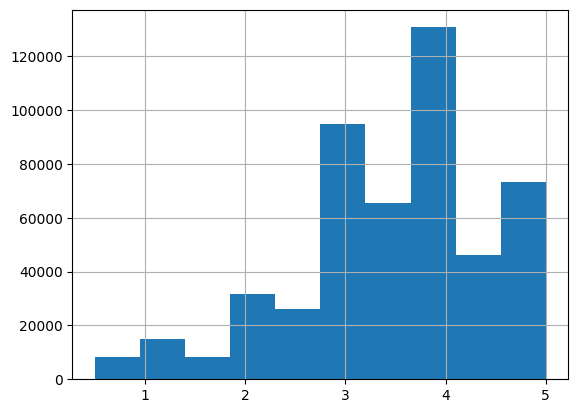

In [41]:
ratings['rating'].hist()

In [7]:
tags.shape

(2328315, 4)

In [42]:
movies['genres'].str.split('|').explode().value_counts()

genres
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
Name: count, dtype: int64

In [9]:
movies_genre = movies.copy()
movies_genre.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


För att minska minnesanvändning och beräkningstid används ett delmängd på 5000 filmer.

In [10]:
movies_genre = movies.sample(5000, random_state=42).reset_index(drop=True)

## Genre-Based Recommendation (Baseline)

Denna modell rekommenderar filmer baserat enbart på genrer.
Genrer omvandlas till numeriska representationer med one-hot encoding och likhet beräknas med cosine similarity.

In [11]:
movies_genre["genres_list"] = movies_genre["genres"].apply(lambda x: x.split("|"))
movies_genre[["title", "genres", "genres_list"]].head()

,title,genres,genres_list
0,The Rape of Recy Taylor (2017),Documentary,[Documentary]
1,Moonlight Shadow (2021),Drama,[Drama]
2,5 to 7 (2014),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
3,Same Kind of Different as Me (2017),Drama,[Drama]
4,Lady in the Water (2006),Drama|Fantasy|Mystery,"[Drama, Fantasy, Mystery]"


In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies_genre["genres_list"])

genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=movies_genre.index)
genre_df.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

genre_similarity = cosine_similarity(genre_df)

In [14]:
def recommend_by_genre(movies_title, movies_df, similarity_matrix, top_n=5):
    matches = movies_df[movies_df["title"].str.contains(movies_title, case=False, na=False)]
    
    if matches.empty:
        return "Movie not found."
    
    movie_idx = matches.index[0]
    
    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    return movies_df.iloc[movie_indices][["title", "genres"]]

In [15]:
recommend_by_genre("Toy Story", movies_genre, genre_similarity)

,title,genres
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children
129,VeggieTales: Sumo of the Opera (2004),Animation|Children
150,The Kindly Lion (1970),Animation|Children
217,Food for Feudin' (1950),Animation|Children
280,LEGO DC Super Heroes: Justice League - Attack ...,Animation|Children


In [16]:
recommend_by_genre("Batman", movies_genre, genre_similarity)

,title,genres
131,Astro Boy (2009),Action|Animation|Children|Sci-Fi
859,Spider-Ham: Caught in a Ham (2019),Action|Animation|Children|Comedy
1186,"Powerpuff Girls, The (2002)",Action|Animation|Children|Comedy
9,The Adventures of Scamper the Penguin (1986),Animation|Children
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children


In [17]:
recommend_by_genre("Matrix", movies_genre, genre_similarity)

'Movie not found.'

## Content-Based Recommendation med TF-IDF
I denna del kombineras genrer och användartaggar för att skapa en mer informativ representation av varje film.
TF-IDF används för att omvalda textdata till numeriska features.

In [18]:
tags_subset = tags[tags["movieId"].isin(movies_genre["movieId"])].copy()
tags_subset.head()

,userId,movieId,tag,timestamp
39,37,589,action,1578164676
40,37,589,classic,1578164653
93,37,7153,epic,1578167749
94,37,7153,fantasy,1578167744
95,37,7153,great soundtrack,1578167755


In [19]:
tags_grouped = tags_subset.groupby("movieId")["tag"].apply(lambda x: " ".join(x.astype(str))).reset_index()
tags_grouped.head()

,movieId,tag
0,126,neverending story unnecessary sequel based on ...
1,129,Nudity (Topless - Notable) nudity (topless)
2,149,amnesia bad acting AMNESIA cerebral deliberate...
3,229,Roman Polanski great acting low budget suspens...
4,256,Arnold Schwarzenegger pregnant man Arnold Schw...


In [20]:
movies_content = movies_genre.merge(tags_grouped, on="movieId", how="left")
movies_content.head()

,movieId,title,genres,genres_list,tag
0,189019,The Rape of Recy Taylor (2017),Documentary,[Documentary],tivo18 1940s alabama racism rape sexual assault
1,268374,Moonlight Shadow (2021),Drama,[Drama],NaN
2,134021,5 to 7 (2014),Comedy|Drama|Romance,"[Comedy, Drama, Romance]",affair corny ending relationships New York Cit...
3,177245,Same Kind of Different as Me (2017),Drama,[Drama],art dealer based on a true story based on memo...
4,45730,Lady in the Water (2006),Drama|Fantasy|Mystery,"[Drama, Fantasy, Mystery]",M. Night Shyamalan what the hell was that? M. ...


In [21]:
movies_content["tag"] = movies_content["tag"].fillna("")

In [22]:
movies_content["genres_text"] = movies_content["genres"].str.replace("|", " ", regex=False)

In [23]:
movies_content["content"] = movies_content["genres_text"] + " " + movies_content["tag"]
movies_content[["title", "content"]].head()

,title,content
0,The Rape of Recy Taylor (2017),Documentary tivo18 1940s alabama racism rape s...
1,Moonlight Shadow (2021),Drama
2,5 to 7 (2014),Comedy Drama Romance affair corny ending relat...
3,Same Kind of Different as Me (2017),Drama art dealer based on a true story based o...
4,Lady in the Water (2006),Drama Fantasy Mystery M. Night Shyamalan what ...


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies_content["content"])

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

content_similarity = cosine_similarity(tfidf_matrix)

In [26]:
def recommend_by_content(movie_title, movies_df, similarity_matrix, top_n=5):
    matches = movies_df[movies_df["title"].str.contains(movie_title, case=False, na=False)]
    
    if matches.empty:
        return "Movie not found"
    
    movie_idx = matches.index[0]
    
    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    
    return movies_df.iloc[movie_indices][["title", "genres", "tag"]]

In [27]:
recommend_by_content("Toy Story", movies_content, content_similarity)

,title,genres,tag
1331,Toy Story Toons: Hawaiian Vacation (2011),Adventure|Animation|Children|Comedy|Fantasy,Pixar short anthropomorphic toy barbie buzz li...
655,Day & Night (2010),Animation|Children,memasa's movies Pixar tolerance Animation bea...
642,Chef Donald (1941),Animation,short
1353,Manoman (2015),Animation|Drama,short
4845,Noir-soleil (2021),Animation,short film


In [28]:
recommend_by_genre("Toy Story", movies_genre, genre_similarity)

,title,genres
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children
129,VeggieTales: Sumo of the Opera (2004),Animation|Children
150,The Kindly Lion (1970),Animation|Children
217,Food for Feudin' (1950),Animation|Children
280,LEGO DC Super Heroes: Justice League - Attack ...,Animation|Children


In [29]:
recommend_by_content("Batman", movies_content, content_similarity)

,title,genres,tag
4939,Barbie in Princess Power (2015),Animation|Children,barbie princess super power
859,Spider-Ham: Caught in a Ham (2019),Action|Animation|Children|Comedy,
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children,
129,VeggieTales: Sumo of the Opera (2004),Animation|Children,
150,The Kindly Lion (1970),Animation|Children,


In [30]:
recommend_by_genre("Batman", movies_genre, genre_similarity)

,title,genres
131,Astro Boy (2009),Action|Animation|Children|Sci-Fi
859,Spider-Ham: Caught in a Ham (2019),Action|Animation|Children|Comedy
1186,"Powerpuff Girls, The (2002)",Action|Animation|Children|Comedy
9,The Adventures of Scamper the Penguin (1986),Animation|Children
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children


## KNN-Baserad Rekommendation 
Istället för att beräkna en fullständig likhetsmatris används KNN för att hitta närmaste filmerna. Detta minskar minnesanvändning och gör modellen mer skalbar.

In [31]:
from sklearn.neighbors import NearestNeighbors

In [32]:
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [33]:
def recommend_by_knn(movie_title, movies_df, model, matrix, top_n=5):
    matches = movies_df[movies_df["title"].str.contains(movie_title, case=False, na=False)]
    
    if matches.empty:
        return "Movie not found."
    
    movie_idx = matches.index[0]
    
    distances, indices = model.kneighbors(matrix[movie_idx], n_neighbors=top_n+1)
    
    movie_indices = indices.flatten()[1:]
    
    return movies_df.iloc[movie_indices][["title", "genres", "tag"]]

In [34]:
recommend_by_knn("Toy Story", movies_content, knn_model, tfidf_matrix)

,title,genres,tag
1331,Toy Story Toons: Hawaiian Vacation (2011),Adventure|Animation|Children|Comedy|Fantasy,Pixar short anthropomorphic toy barbie buzz li...
655,Day & Night (2010),Animation|Children,memasa's movies Pixar tolerance Animation bea...
642,Chef Donald (1941),Animation,short
1353,Manoman (2015),Animation|Drama,short
4845,Noir-soleil (2021),Animation,short film


In [35]:
recommend_by_content("Toy Story", movies_content, content_similarity)

,title,genres,tag
1331,Toy Story Toons: Hawaiian Vacation (2011),Adventure|Animation|Children|Comedy|Fantasy,Pixar short anthropomorphic toy barbie buzz li...
655,Day & Night (2010),Animation|Children,memasa's movies Pixar tolerance Animation bea...
642,Chef Donald (1941),Animation,short
1353,Manoman (2015),Animation|Drama,short
4845,Noir-soleil (2021),Animation,short film


In [36]:
recommend_by_genre("Toy Story", movies_genre, genre_similarity)

,title,genres
126,"Someday You'll Find Her, Charlie Brown (1981)",Animation|Children
129,VeggieTales: Sumo of the Opera (2004),Animation|Children
150,The Kindly Lion (1970),Animation|Children
217,Food for Feudin' (1950),Animation|Children
280,LEGO DC Super Heroes: Justice League - Attack ...,Animation|Children


## Slutsats
Den genre-baserade modellen är enkel men ger begränsade rekommendationer. 

TF-IDF modellen förbättrar resultaten genom att använda mer information.

KNN metoden ger en bra balans mellan prestanda och effektivitet.